# Exploratory Data Analysis

Explore the processed churn dataset: distributions, churn rates by segment, and key drivers. Run **00_data_preprocessing** first so `data/processed/churn_features.csv` exists.

| Source | Churn = 1 means |
|--------|------------------|
| **Olist** (Brazilian e-commerce) | No purchase in the **last 90+ days** (inactive), **or** average review score **&lt; 2** (very dissatisfied). So: "has not bought recently" or "very unhappy." |
| **Labeled** (subscription dataset) | Customer **cancelled or paused** their subscription. So: they ended or paused the relationship. |

## 1. Load data and setup

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PROCESSED = Path("../data/processed")
df = pd.read_csv(DATA_PROCESSED / "churn_features.csv")
print("Shape:", df.shape)
df.head()

Shape: (98096, 8)


,customer_id,recency,tenure_days,frequency,monetary,avg_review,churn,source
0,0000366f3b9a7992bf8c76cfdf3221e2,160,160,1,141.90,5.0,1,Olist
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,163,1,27.19,4.0,1,Olist
2,0000f46a3911fa3c0805444483337064,585,585,1,86.22,3.0,1,Olist
3,0000f6ccb0745a6a4b88665a16c9f078,369,369,1,43.62,4.0,1,Olist
4,0004aac84e0df4da2b147fca70cf8255,336,336,1,196.89,5.0,1,Olist


## 2. Overview: dtypes, describe, missing values

In [21]:
df.dtypes

customer_id     object
recency          int64
tenure_days      int64
frequency        int64
monetary       float64
avg_review     float64
churn            int64
source          object
dtype: object

In [22]:
df.describe()

,recency,tenure_days,frequency,monetary,avg_review,churn
count,98096.000000,98096.000000,98096.000000,98096.000000,98096.000000,98096.000000
mean,294.718429,310.754750,1.526637,184.111103,4.084963,0.897264
std,169.825493,212.124119,3.968997,271.333718,1.322957,0.303615
min,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,164.000000,168.000000,1.000000,63.790000,4.000000,1.000000
50%,271.000000,275.000000,1.000000,110.405000,5.000000,1.000000
75%,402.000000,412.000000,1.000000,189.845000,5.000000,1.000000
max,1795.000000,1826.000000,49.000000,13664.080000,5.000000,1.000000


In [23]:
df.isna().sum()

customer_id    0
recency        0
tenure_days    0
frequency      0
monetary       0
avg_review     0
churn          0
source         0
dtype: int64

## 3. Churn rate by source

In [24]:
# Overall and by source (Olist vs Labeled)
print("Overall churn rate:", df["churn"].mean().round(3))
df.groupby("source")["churn"].agg(["mean", "sum", "count"])

Overall churn rate: 0.897


,mean,sum,count
source,,,
Labeled,0.398000,796,2000
Olist,0.907655,87222,96096


## 4. Distributions of key features

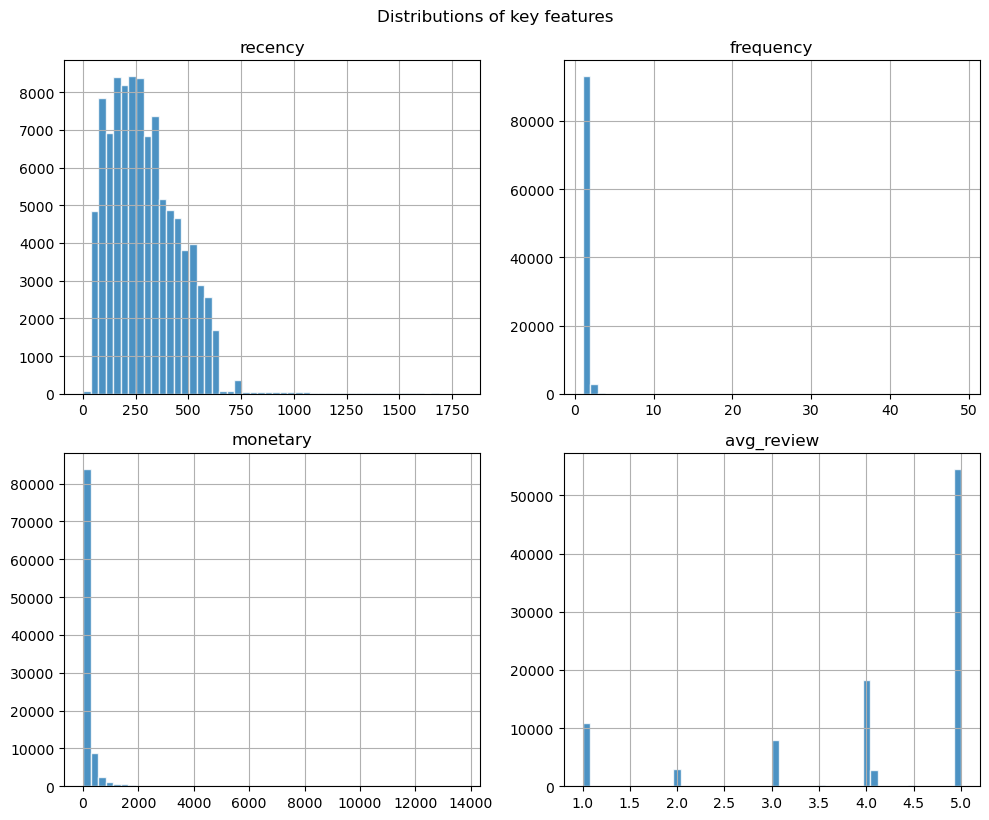

In [25]:
# Recency, frequency, monetary, avg_review
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flat, ["recency", "frequency", "monetary", "avg_review"]):
    df[col].hist(ax=ax, bins=50, edgecolor="white", alpha=0.8)
    ax.set_title(col)
plt.tight_layout()
plt.suptitle("Distributions of key features", y=1.02)
plt.show()

## 5. Churn vs features (e.g. recency, satisfaction)

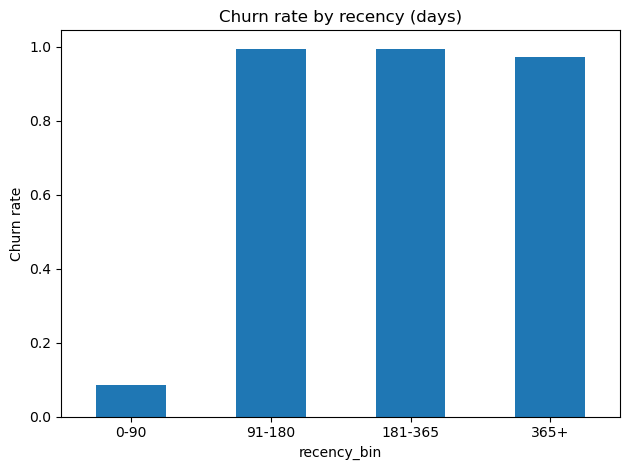

In [26]:
# Churn rate by recency bins and by avg_review
df["recency_bin"] = pd.cut(df["recency"], bins=[0, 90, 180, 365, df["recency"].max() + 1], labels=["0-90", "91-180", "181-365", "365+"])
churn_by_recency = df.groupby("recency_bin", observed=True)["churn"].mean()
churn_by_recency.plot(kind="bar", title="Churn rate by recency (days)")
plt.ylabel("Churn rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

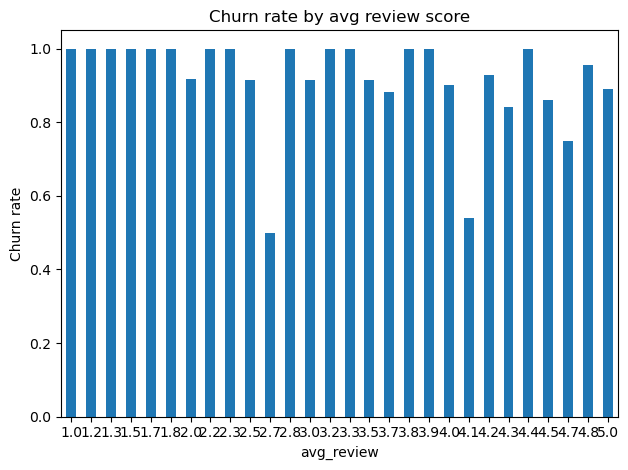

In [27]:
# Churn rate by avg_review (satisfaction)
df.groupby(df["avg_review"].round(1))["churn"].mean().plot(kind="bar", title="Churn rate by avg review score")
plt.ylabel("Churn rate")
plt.xlabel("avg_review")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Correlations (numeric features vs churn)

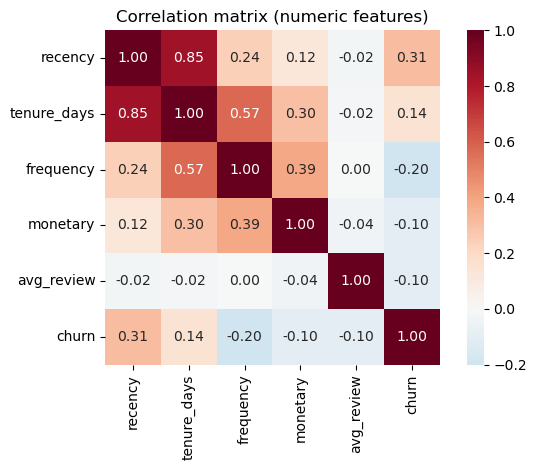

In [28]:
numeric = ["recency", "tenure_days", "frequency", "monetary", "avg_review", "churn"]
corr = df[numeric].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()